# Practical Session 4A: Quadratic Optimization, Projection, and Regularization

This notebook covers the first half of Session 4: constrained least squares,
projection onto the probability simplex, and the regularization parameter study.


In [1]:
# Import time so the generic and specialized projection methods can be timed.
import time
# Import NumPy for matrix computations.
import numpy as np
# Import pandas for tabular comparison outputs.
import pandas as pd
# Import cvxpy for quadratic optimization models.
import cvxpy as cp
# Import Matplotlib for the regularization plots.
import matplotlib.pyplot as plt

# Keep printed arrays compact.
np.set_printoptions(precision=4, suppress=True)
# Select a QP solver that is available in the environment.
SOLVER = "CLARABEL" if "CLARABEL" in cp.installed_solvers() else "SCS"
# Fix the random seed so all generated data sets are reproducible.
rng = np.random.default_rng(123)


## Task 1: Constrained least squares as a quadratic program

We generate random data, solve the least-squares problem with simplex-like constraints,
and inspect both the primal solution and selected dual quantities.


In [2]:
# Problem dimensions from the practical script.
m, n = 40, 10
# Generate a random measurement matrix.
A = rng.normal(size=(m, n))
# Generate a random right-hand-side vector.
b = rng.normal(size=m)

# Create the optimization vector.
x = cp.Variable(n)
# Enforce componentwise nonnegativity.
nonnegativity = (x >= 0)
# Enforce that all components sum to one.
# TODO: Enforce that the vector lies on the simplex.
simplex_constraint = ...
# Build the constrained least-squares objective.
# TODO: Build the constrained least-squares problem.
cls_problem = ...
cls_problem.solve(solver=SOLVER)

# Extract the optimal vector as a NumPy array.
x_star = x.value
# Compute the residual norm requested in the task.
residual_norm = np.linalg.norm(A @ x_star - b)
print("Status:", cls_problem.status)
print("Residual norm:", residual_norm)
print("Sum of components:", x_star.sum())
print("Minimum component:", x_star.min())
# Show dual variables to connect the numerical solution to Lagrange multiplier ideas.
print("Equality constraint dual value:", simplex_constraint.dual_value)
print("First five nonnegativity dual values:", nonnegativity.dual_value[:5])
print("Optimal vector x*:", np.round(x_star, 4))


Status: optimal
Residual norm: 5.603547430563139
Sum of components: 0.9999999999999944
Minimum component: 2.059872282720699e-10
Equality constraint dual value: -2.887319075596357
First five nonnegativity dual values: [0.     2.3633 0.     0.     1.933 ]
Optimal vector x*: [0.0726 0.     0.1139 0.1151 0.     0.1849 0.2904 0.     0.1636 0.0594]


## Task 2: Projection onto the probability simplex

The same simplex constraint is now used in a pure projection problem. We solve it once
with `cvxpy` and once with a specialized sorting-based algorithm.


In [3]:
# Draw the vector that will be projected onto the simplex.
y = rng.normal(size=20)


def simplex_projection_sort(v):
    # Sort the entries in descending order to find the active set.
    u = np.sort(v)[::-1]
    # Compute cumulative sums shifted by one for the projection formula.
    cssv = np.cumsum(u) - 1
    # Find the largest index for which the thresholded solution stays positive.
    rho = np.nonzero(u - cssv / (np.arange(len(v)) + 1) > 0)[0][-1]
    # Compute the threshold theta of the simplex projection.
    # TODO: Compute the projection threshold theta.
    theta = ...
    # Shift and clip the vector to obtain the projected point.
    return np.maximum(v - theta, 0)


# Create the generic projection variable.
x_proj = cp.Variable(20)
# Minimize the squared Euclidean distance to y under simplex constraints.
simplex_problem = cp.Problem(
    cp.Minimize(0.5 * cp.sum_squares(x_proj - y)),
    [x_proj >= 0, cp.sum(x_proj) == 1],
)

# Time the generic QP solve.
start = time.perf_counter()
simplex_problem.solve(solver=SOLVER)
runtime_cvxpy = time.perf_counter() - start
projection_cvxpy = x_proj.value

# Time the dedicated projection algorithm.
start = time.perf_counter()
projection_algorithm = simplex_projection_sort(y)
runtime_algorithm = time.perf_counter() - start

# Compare both outputs entry by entry.
comparison = pd.DataFrame(
    {
        "cvxpy": projection_cvxpy,
        "algorithm": projection_algorithm,
        "abs_diff": np.abs(projection_cvxpy - projection_algorithm),
    }
)
display(comparison.head(10))
print("Runtime cvxpy:", runtime_cvxpy)
print("Runtime dedicated algorithm:", runtime_algorithm)
print("Maximum absolute difference:", np.max(np.abs(projection_cvxpy - projection_algorithm)))


,cvxpy,algorithm,abs_diff
0,3.141140e-01,0.314119,5.132882e-06
1,1.139379e-09,0.000000,1.139379e-09
2,1.311315e-09,0.000000,1.311315e-09
3,5.836500e-10,0.000000,5.836500e-10
4,5.960917e-10,0.000000,5.960917e-10
5,1.071174e-09,0.000000,1.071174e-09
6,8.496373e-10,0.000000,8.496373e-10
7,1.421812e-09,0.000000,1.421812e-09
8,6.697092e-10,0.000000,6.697092e-10
9,4.365460e-09,0.000000,4.365460e-09


Runtime cvxpy: 0.019150083000006646
Runtime dedicated algorithm: 0.0004817919999950959
Maximum absolute difference: 1.01828425073232e-05


## Task 3: Parameter study for regularized least squares

We vary the regularization parameter `lambda` and record the trade-off between data fit
and solution size.


,lambda,residual_norm,solution_norm
0,0.001000,5.407056,0.171401
1,0.001833,5.407056,0.171396
2,0.003360,5.407056,0.171386
3,0.006158,5.407056,0.171368
4,0.011288,5.407056,0.171335


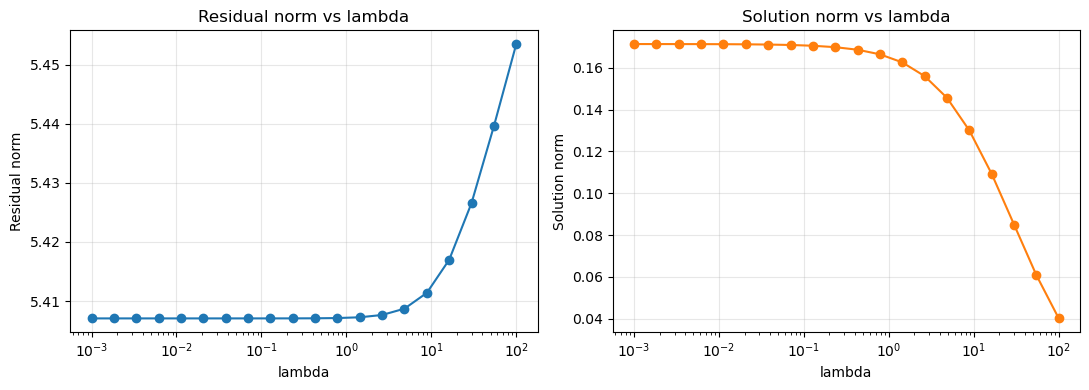

In [4]:
# Use a logarithmic grid so both small and large lambda values are visible.
lambda_grid = np.logspace(-3, 2, 20)
regularization_rows = []

for lam in lambda_grid:
    # Create a fresh optimization variable for the current lambda value.
    x_reg = cp.Variable(n)
    # Add an L2 penalty to the least-squares objective.
    problem = cp.Problem(
        cp.Minimize(0.5 * cp.sum_squares(A @ x_reg - b) + 0.5 * lam * cp.sum_squares(x_reg)),
        [x_reg >= 0],
    )
    problem.solve(solver=SOLVER)
    x_value = x_reg.value
    regularization_rows.append(
        {
            "lambda": lam,
            "residual_norm": np.linalg.norm(A @ x_value - b),
            # TODO: Record the Euclidean norm of the solution vector.
            "solution_norm": ...,
        }
    )

# Convert the sweep results into a DataFrame for inspection.
regularization_df = pd.DataFrame(regularization_rows)
display(regularization_df.head())

# Plot both monitored quantities against lambda.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogx(regularization_df["lambda"], regularization_df["residual_norm"], marker="o")
axes[0].set_title("Residual norm vs lambda")
axes[0].set_xlabel("lambda")
axes[0].set_ylabel("Residual norm")
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(
    regularization_df["lambda"],
    regularization_df["solution_norm"],
    marker="o",
    color="tab:orange",
)
axes[1].set_title("Solution norm vs lambda")
axes[1].set_xlabel("lambda")
axes[1].set_ylabel("Solution norm")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
